In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

In [38]:
df3 = pd.read_pickle('../data/df3_with_regions.pkl')

In [39]:
df3[df3['CRD_NUM'] == 138002869340].to_csv('../data/check.csv')

data overview

In [20]:
n_rides = len(df3)
n_patrons = df3['CRD_NUM'].nunique()
n_missing_info = len(df3[df3['missing_info'] == True])
n_neg_time_gap = len(df3[df3['time_gap_mins'] < 0])

In [23]:
print("Number of Rides: " + str(n_rides))
print("Number of Unique Patrons: " + str(n_patrons))
print("Number of Rides Missing Critical Information: " + str(n_missing_info))
print("Percentage of Rides Missing Critical Information: " + str(n_missing_info / n_rides * 100) + '%')
print("Number of Rides with Negative Time Gaps: " + str(n_neg_time_gap))

Number of Rides: 7468612
Number of Unique Patrons: 2453068
Number of Rides Missing Critical Information: 68010
Percentage of Rides Missing Critical Information: 0.9106109676068324%
Number of Rides with Negative Time Gaps: 665


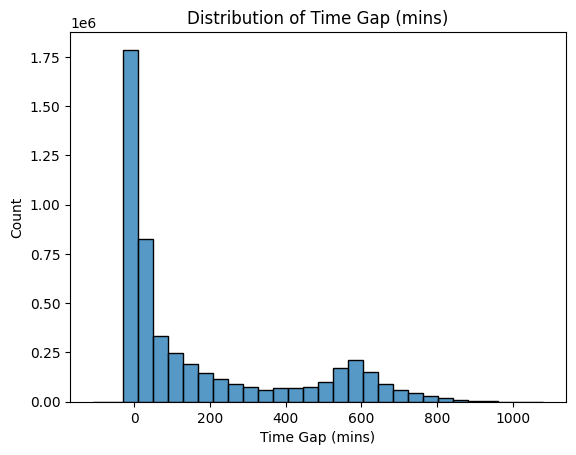

In [11]:
sns.histplot(df3['time_gap_mins'], bins=30)
plt.xlabel('Time Gap (mins)')
plt.title('Distribution of Time Gap (mins)')
plt.show()

In [49]:
df = df3[df3['time_gap_mins'] >= 0]

# Cap extreme values (e.g., 99th percentile)
upper = df['time_gap_mins'].quantile(0.99)
df_plot = df[df['time_gap_mins'] <= upper]

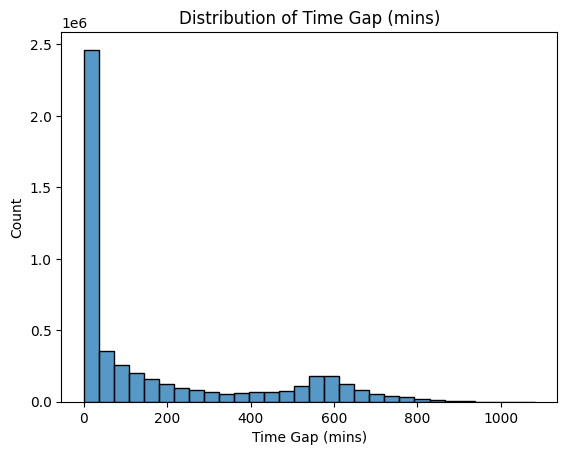

In [50]:
sns.histplot(df['time_gap_mins'], bins=30)
plt.xlabel('Time Gap (mins)')
plt.title('Distribution of Time Gap (mins)')
plt.show()

Text(0.5, 1.0, 'Time Gap by Hour')

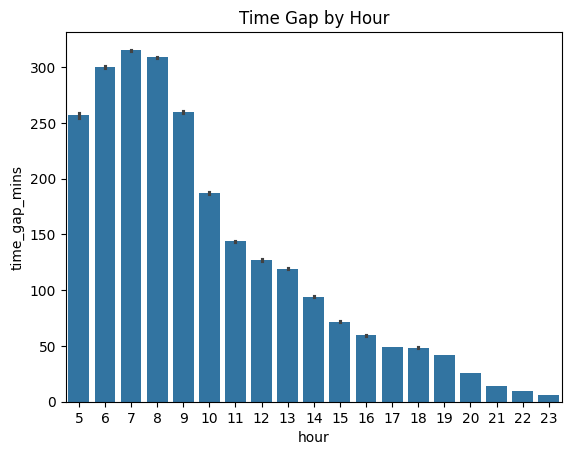

In [51]:
df['hour'] = df['ENTRY_TM'].dt.hour

# Time gap by hour
sns.barplot(x='hour', y='time_gap_mins', data=df)
plt.title('Time Gap by Hour')

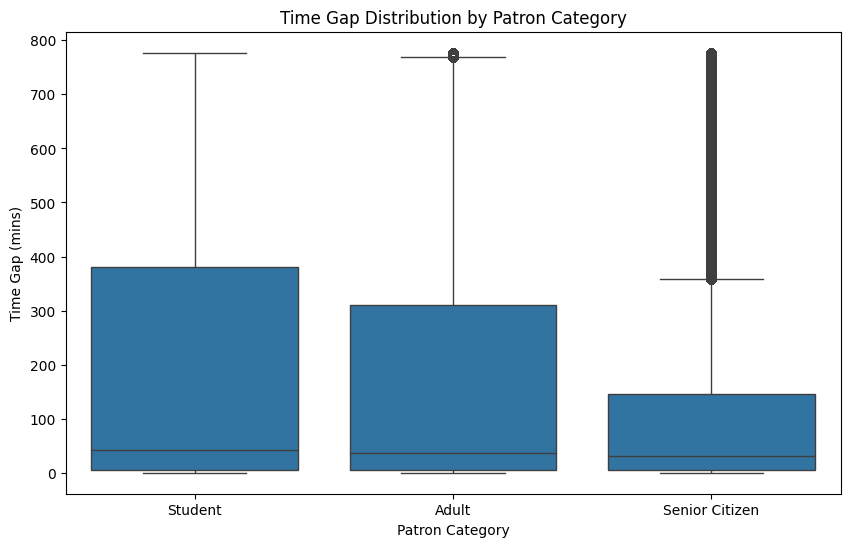

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_plot,
    x='PATRON_CATG_DESC_TXT',
    y='time_gap_mins'
)

plt.title('Time Gap Distribution by Patron Category')
plt.xlabel('Patron Category')
plt.ylabel('Time Gap (mins)')
plt.show()

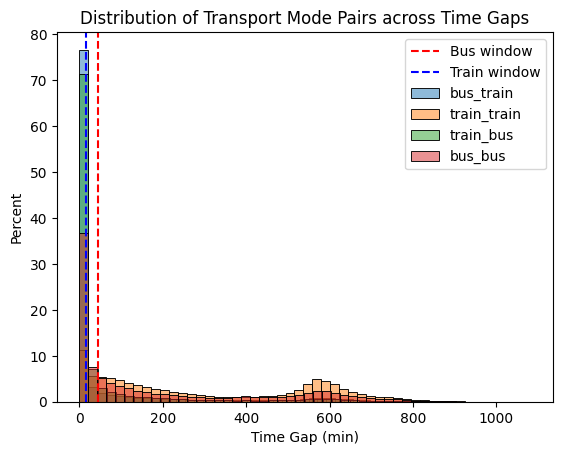

In [43]:
mode_pairs = df['mode_pair'].unique()
for pair in mode_pairs:
    subset = df[df['mode_pair'] == pair]
    sns.histplot(subset['time_gap_mins'], bins=50, label=pair, alpha=0.5, stat='percent')
plt.axvline(45, color='red', linestyle='--', label='Bus window')
plt.axvline(15, color='blue', linestyle='--', label='Train window')
plt.legend()
plt.title('Distribution of Transport Mode Pairs across Time Gaps')
plt.xlabel('Time Gap (min)')
plt.show()

In [39]:
# Proportion inside/outside windows
bus_involved = df[df['mode_pair'].str.contains('bus')]
bus_allowed_pct = (bus_involved['time_gap_mins'] <= 45).mean() * 100
train_train = df[df['mode_pair'] == 'train_train']
train_allowed_pct = (train_train['time_gap_mins'] <= 15).mean() * 100

print('Proportion of bus-bus/bus-train/train-bus within window: ' + str(bus_allowed_pct))
print('Proportion of train-train within window: ' + str(train_allowed_pct))

Proportion of bus-bus/bus-train/train-bus within window: 62.84334135214669
Proportion of train-train within window: 9.408103344163543


In [ ]:
# Top origins and destinations
top_10_origins = df['ORIG_STATION_NAME'].value_counts(normalize=True).head(10) * 100
top_10_dests = df['DEST_STATION_NAME'].value_counts(normalize=True).head(10) * 100

# Same station consecutive
same_station_pct = (df['ORIG_STATION_NAME'] == df['next_orig_station']).mean() * 100

# Regional transfer volumes
region_transfers = df.groupby(['orig_region', 'dest_region']).size().reset_index(name='count')

print('Top 10 Most Popular Origin Stations (percentage): ')
print(top_10_origins)
print('Top 10 Most Popular Destination Stations (percentage): ')
print(top_10_dests)
print('Percentage of Rides where the Next Ride Entry Station is the Current Exit Station: ' + str(same_station_pct))

Top 10 Most Popular Origin Stations (percentage): 
ORIG_STATION_NAME
Jurong East      0.942552
Raffles Place    0.919107
Yishun           0.719799
Clementi         0.678732
Orchard NSEW     0.667900
Boon Lay         0.629712
Sengkang         0.627141
Admiralty        0.614836
Tanjong Pagar    0.609761
Punggol          0.606520
Name: proportion, dtype: float64
Top 10 Most Popular Destination Stations (percentage): 
DEST_STATION_NAME
Jurong East       0.951139
Raffles Place     0.921030
Yishun            0.781869
Boon Lay          0.759516
Clementi          0.724339
Orchard NSEW      0.669820
Ang Mo Kio        0.667360
Sengkang          0.653287
Tanjong Pagar     0.626404
Woodlands NSEW    0.619912
Name: proportion, dtype: float64
Percentage of Rides where the Next Ride Entry Station is the Current Exit Station: 0.41057861723303335


In [ ]:
# Transfer rate by hour
hourly_transfer = df.groupby('hour')['is_same_journey_final'].mean() * 100

print('Transfer Rate by Hour:')
print(hourly_transfer)

Transfer Rate by Hour:
hour
5     43.581533
6     37.042722
7     31.967458
8     27.924019
9     25.379561
10    24.191657
11    22.049043
12    20.808443
13    20.282096
14    22.599442
15    24.568964
16    24.894737
17    25.834444
18    22.875000
19    20.515764
20    22.865537
21    24.993887
22    24.773307
23    15.735209
Name: is_same_journey_final, dtype: float64


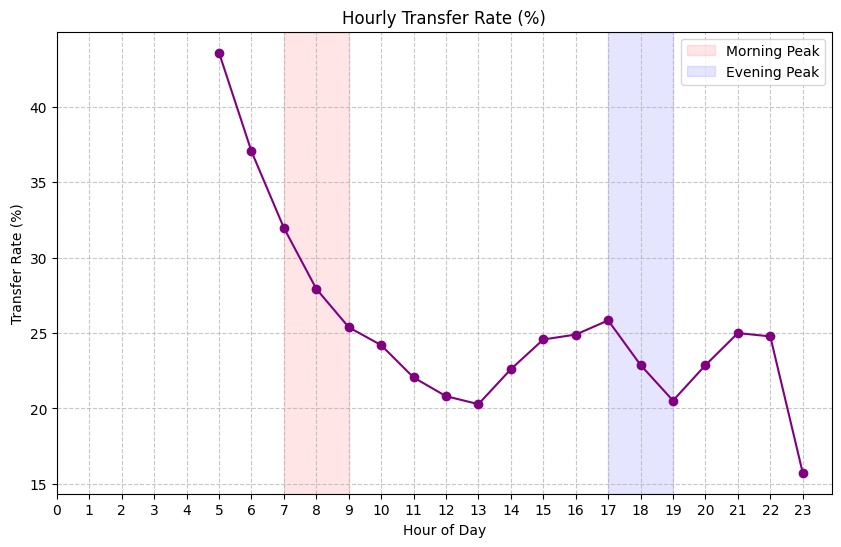

In [52]:
plt.figure(figsize=(10,6))

hourly_transfer.plot(marker='o', linestyle='-', color='purple', label="_nolegend_")

plt.axvspan(7, 9, color='red', alpha=0.1, label='Morning Peak')
plt.axvspan(17, 19, color='blue', alpha=0.1, label='Evening Peak')

plt.xlabel('Hour of Day')
plt.ylabel('Transfer Rate (%)')
plt.title('Hourly Transfer Rate (%)')
plt.xticks(range(0,24))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# if necessary
%who
del n_rides, n_patrons, n_missing_info, n_neg_time_gap, mode_pairs, bus_involved, bus_allowed_pct, train_train, train_allowed_pct, top_10_origins, 
top_10_dests, same_station_pct, region_transfers, hourly_transfer, df3, df_plot
gc.collect()

transfers analysis

In [ ]:
df2 = df[df['BTS_flag'] == False]

In [ ]:
# percentage of transfers from each patron category

transfers_patron_cat = (
    df2['PATRON_CATG_DESC_TXT']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename('percentage_of_transfers')
)

transfers_patron_cat

PATRON_CATG_DESC_TXT
Adult             69.49
Senior Citizen    18.64
Student           11.87
Name: percentage_of_transfers, dtype: float64

In [21]:
# percentage of each patron category's rides that are transfers

transfers_per_patron_cat = (
    df3.groupby('PATRON_CATG_DESC_TXT')['is_same_journey_final']
    .mean()
    .mul(100)
    .round(2)
    .rename('transfer_pct')
)

print(transfers_per_patron_cat)

PATRON_CATG_DESC_TXT
Adult             25.70
Senior Citizen    28.06
Student           27.08
Name: transfer_pct, dtype: float64


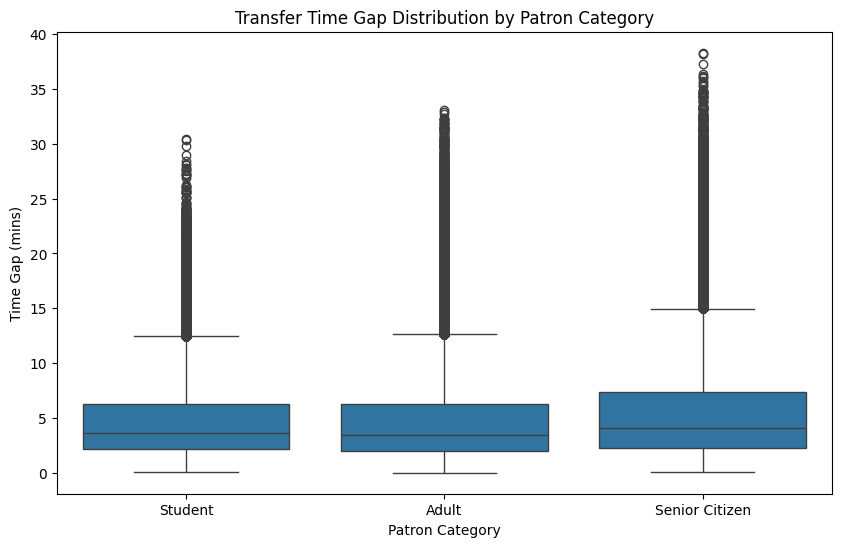

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df2,
    x='PATRON_CATG_DESC_TXT',
    y='time_gap_mins'
)

plt.title('Transfer Time Gap Distribution by Patron Category')
plt.xlabel('Patron Category')
plt.ylabel('Time Gap (mins)')
plt.show()

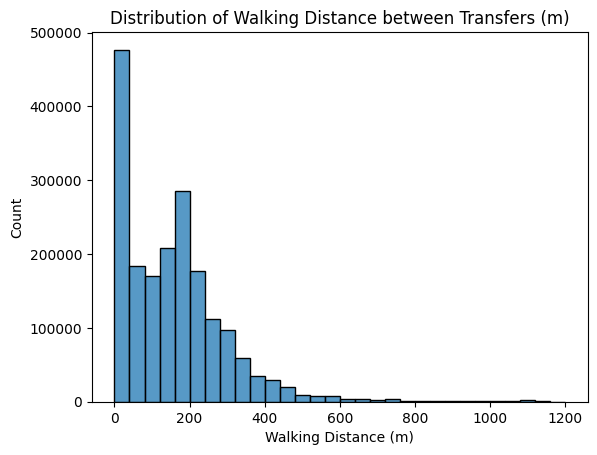

In [42]:
sns.histplot(df2['walk_distance'], bins=30)
plt.xlabel('Walking Distance (m)')
plt.title('Distribution of Walking Distance between Transfers (m)')
plt.show()

In [ ]:
# ignore because I realised we don't have temporal_flag and spatial_flag
'''
transfers_pct = df3['is_same_journey_final'].value_counts(normalize=True) * 100
print('Percentage of Rides Identified as Transfers by Classifier: ' + str(transfers_pct))

for flag in ['binary_flag','temporal_flag','spatial_flag']:
    flag_pct = df3[flag].value_counts(normalize=True) * 100
    print(f'Percentage of Rides Identified as Transfers by {flag}: ' + str(flag_pct))
'''

In [ ]:
# if necessary
%who
del df2
gc.collect()

final termination reasons by patron category (excluding transfers, journey termination and return/intermediate trips)

In [41]:
df_explode = df3[(df3['BTS_flag']) &
                (~df3['BTS_flag_reason'].str.contains('null_walk_distance', na=False)) &
                (~df3['BTS_flag_reason'].str.contains('null_time_gap', na=False)) &
                (~df3['BTS_flag_reason'].str.contains('null_predicted_walking_time', na=False)) &
                (~df3['BTS_flag_reason'].str.contains('missing_info', na=False))].copy()

In [31]:
%who
del df3
gc.collect()

df3	 df_explode	 df_plot	 df_termination	 g	 gc	 n_missing_info	 n_neg_time_gap	 n_patrons	 
n_rides	 p	 patrons	 pd	 plt	 sns	 subset	 


13424

In [42]:
# split BTS_flag_reasons so that each row only has 1 reason
df_explode['BTS_flag_exploded'] = df_explode['BTS_flag_reason'].str.split(r' \| ')
df_exploded = df_explode.explode('BTS_flag_exploded')

In [33]:
# if necessary
%who
del df_explode
gc.collect()

df_explode	 df_exploded	 df_plot	 df_termination	 g	 gc	 n_missing_info	 n_neg_time_gap	 n_patrons	 
n_rides	 p	 patrons	 pd	 plt	 sns	 subset	 


0

In [43]:
df_plot = df_exploded.groupby(['PATRON_CATG_DESC_TXT', 'BTS_flag_exploded']).size().reset_index(name='count')

# percentage within each patron category
df_plot['percentage'] = df_plot.groupby('PATRON_CATG_DESC_TXT')['count'].transform(lambda x: x / x.sum() * 100)

order = (
    df_plot.groupby('BTS_flag_exploded')['percentage']
    .mean()
    .sort_values(ascending=False)
    .index
)

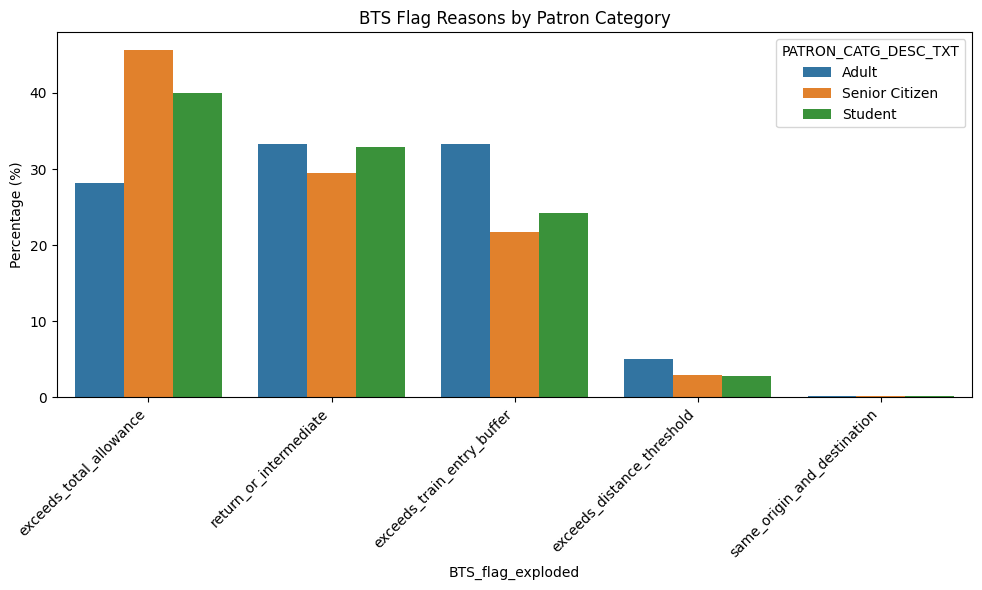

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_plot,
    x='BTS_flag_exploded',
    y='percentage',
    hue='PATRON_CATG_DESC_TXT',
    order=order
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Percentage (%)')
plt.title('BTS Flag Reasons by Patron Category')
plt.tight_layout()
plt.show()

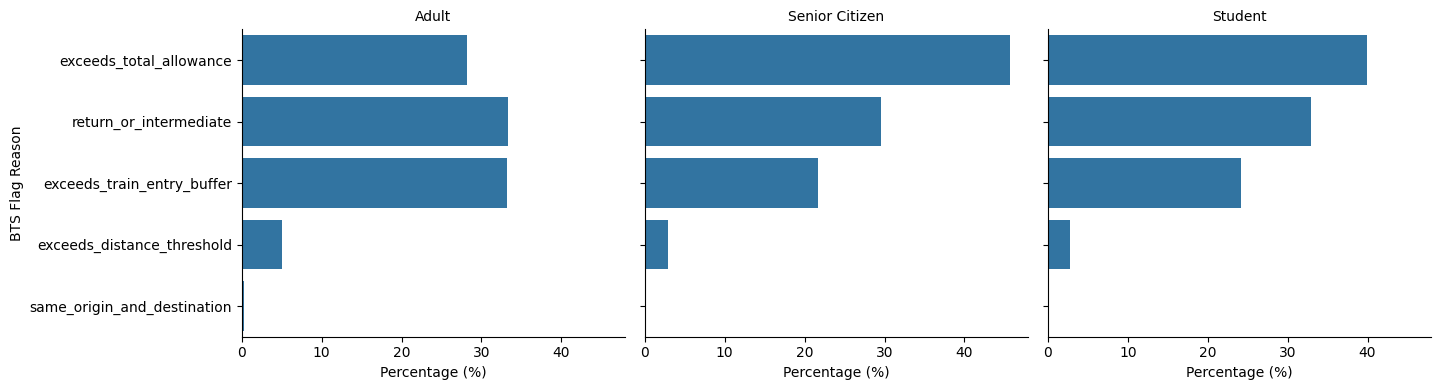

In [46]:
sep_graphs = sns.catplot(
    data=df_plot,
    y='BTS_flag_exploded',
    x='percentage',
    col='PATRON_CATG_DESC_TXT',
    kind='bar',
    col_wrap=3,
    sharex=True,
    height=4,
    aspect=1.2, 
    order=order
)

sep_graphs.set_axis_labels("Percentage (%)", "BTS Flag Reason")
sep_graphs.set_titles("{col_name}")

plt.tight_layout()
plt.show()

final termination reasons by patron category (percentage, excluding transfers)

In [ ]:
# percentage by patron category
df_exploded.groupby('PATRON_CATG_DESC_TXT')['BTS_flag_exploded'] \
    .value_counts(normalize=True) \
    .reset_index(name='pct_within_group')

In [ ]:
# overall percentage
df_exploded['BTS_flag_exploded'] \
    .value_counts(normalize=True) \
    .reset_index(name='pct_overall') \
    .rename(columns={'index': 'BTS_flag_reason'})

overall transfer metrics by patron category

In [ ]:
# re-read if deleted earlier
df3 = pd.read_pickle('../data/df3_with_regions.pkl')

In [ ]:
df5 = pd.read_pickle('../data/df5.pkl')

In [ ]:
def get_df_val(data, correct_data):
    df = data[['CRD_NUM', 'JRNY_ID_NUM', 'ENTRY_TM', 'EXIT_TM', 'TRNSPT_MODE_CD', 'journey_termination_flag', 
    'ORIG_STATION_NAME', 'dest_region']]
    correct_df = correct_data[['CRD_NUM', 'JRNY_ID_NUM', 'JRNY_START_TM', 'JRNY_END_TM', 'PATRON_CATG_ID_NUM']]

    correct_df['service_day'] = (correct_df['JRNY_START_TM'] - pd.Timedelta(hours=5)).dt.date
    target_day = pd.Timestamp('2025-02-12').date()
    correct_df = correct_df[correct_df['service_day'] == target_day].reset_index(drop=True)
    correct_df = correct_df[correct_df['PATRON_CATG_ID_NUM'].isin([1, 3, 4])].reset_index(drop=True)

    df_val = df.merge(
        correct_df[['CRD_NUM', 'JRNY_ID_NUM', 'JRNY_START_TM', 'JRNY_END_TM']],
        on=['CRD_NUM', 'JRNY_ID_NUM'],
        how='inner'
    )

    df_val = df_val[
        (df_val['ENTRY_TM'] >= df_val['JRNY_START_TM']) &
        (df_val['EXIT_TM'] <= df_val['JRNY_END_TM'])
    ].reset_index(drop=True)

    df_val = df_val.sort_values(['CRD_NUM', 'ENTRY_TM']).reset_index(drop=True)
    df_val['next_JRNY_ID_NUM'] = df_val.groupby('CRD_NUM')['JRNY_ID_NUM'].shift(-1)
    df_val['true_transfer'] = (df_val['JRNY_ID_NUM'] == df_val['next_JRNY_ID_NUM'])
    df_val = df_val[df_val['next_JRNY_ID_NUM'].notna()].reset_index(drop=True)

    return df_val    

In [ ]:
def get_metrics(df):
    actual_transfer = df['true_transfer']
    pred_transfer = ~df['journey_termination_flag_spatial']

    tp = (actual_transfer & pred_transfer).sum()     # actual transfer, predicted transfer
    tn = (~actual_transfer & ~pred_transfer).sum()   # actual new journey, predicted new journey
    fp = (~actual_transfer & pred_transfer).sum()    # actual new journey, predicted transfer (merge error)
    fn = (actual_transfer & ~pred_transfer).sum()    # actual transfer, predicted new journey (split error)

    total_actual_transfers = actual_transfer.sum()

    print(f"TP: {tp:,}  TN: {tn:,}  FP: {fp:,}  FN: {fn:,}")
    print(f"Split rate  (FN / actual transfers): {fn / total_actual_transfers:.4f}")
    print(f"Merge rate  (FP / actual transfers): {fp / total_actual_transfers:.4f}")
    print(f"Sensitivity (TP / (TP+FN)):          {tp / (tp + fn):.4f}")
    print(f"Specificity (TN / (TN+FP)):          {tn / (tn + fp):.4f}")
    print(f"Accuracy    ((TP+TN) / total):       {(tp + tn) / len(df):.4f}")

    print(pd.crosstab(
        actual_transfer,
        pred_transfer,
        rownames=['Actual transfer'],
        colnames=['Predicted transfer']
    ))

In [ ]:
df_val = get_df_val(df3, df5)
get_metrics(df_val)

In [ ]:
for group_name, group_df in df_val.groupby('PATRON_CATG_DESC_TXT'):
    print(f"\nGroup: {group_name}")
    get_metrics(group_df)